# Time Series Analysis in Python
## Box–Jenkins Workflow + Forecasting Benchmarks (SES / Holt / Holt–Winters)

**Reference**: https://otexts.com/fpp2

<a target="_blank" href="https://colab.research.google.com/github/cspun/TSA/blob/tsa-I.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook is for teaching. It illustrates the **full analysis framework** using several real datasets.

**Workflow (Box–Jenkins):**
- Plot series → look for trend/seasonality/outliers.
- Plot ACF/PACF → propose a small AR/ARMA candidate set.
- Fit models → compare AIC/BIC.
- Diagnose residuals → residual ACF should look like white noise; Ljung–Box should not reject.
- Forecast + prediction intervals → point forecast is incomplete without uncertainty.

We also include forecasting benchmarks:
- Simple Exponential Smoothing (SES)
- Holt’s linear trend method
- Holt–Winters’ seasonal method


## 0. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf, yule_walker
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.set_printoptions(precision=4, suppress=True)

### Helper utilities (plots, diagnostics, robust conf-int handling)


In [2]:
def to_2col_array(ci):
    """Return conf_int as a (h,2) numpy array, robust to DataFrame/ndarray."""
    return np.asarray(ci)

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10,5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y)+1)
    y_vals = y.values if hasattr(y, "values") else y
    plt.plot(x_axis, y_vals, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n//2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)

    band = 1.96 / np.sqrt(n)

    # ACF
    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    # PACF
    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p

def residual_report(fit, lags=(8,12,16,20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb

def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)   # just to be safe

    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()

def forecast_table_and_plot(fit, steps, y, title_prefix="Forecast"):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci_arr = to_2col_array(fc.conf_int(alpha=0.05))

    n = len(y)
    idx = np.arange(n+1, n+steps+1)
    fc_df = pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci_arr[:,0],
        "upper_95": ci_arr[:,1],
    }, index=idx)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, n+1), np.asarray(y), label="observed", linewidth=1)
    t_fc = np.arange(n+1, n+steps+1)
    plt.plot(t_fc, mean_fc, label="forecast", linewidth=2)
    plt.fill_between(t_fc, ci_arr[:,0], ci_arr[:,1], alpha=0.2, label="95% PI")
    plt.title(f"{title_prefix}")
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

    return fc_df

def ets_benchmarks(y, seasonal_periods=None, seasonal=None):
    yy = pd.Series(y).astype(float)
    ses = ExponentialSmoothing(yy, trend=None, seasonal=None).fit(optimized=True)
    holt = ExponentialSmoothing(yy, trend="add", seasonal=None, damped_trend=False).fit(optimized=True)
    hw = None
    if seasonal_periods is not None and seasonal is not None:
        hw = ExponentialSmoothing(yy, trend="add", seasonal=seasonal, seasonal_periods=seasonal_periods).fit(optimized=True)
    return ses, holt, hw

def plot_ets_forecasts(y, steps, ses, holt, hw=None, title="ETS benchmarks"):
    yy = np.asarray(y)
    n = len(yy)
    t = np.arange(1, n+1)
    t_fc = np.arange(n+1, n+steps+1)

    f_ses = ses.forecast(steps)
    f_holt = holt.forecast(steps)

    plt.figure(figsize=(10,5))
    plt.plot(t, yy, label="observed", linewidth=1)
    plt.plot(t_fc, f_ses, label="SES", linewidth=2)
    plt.plot(t_fc, f_holt, label="Holt", linewidth=2)
    if hw is not None:
        f_hw = hw.forecast(steps)
        plt.plot(t_fc, f_hw, label="Holt-Winters", linewidth=2)

    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

## Example 1 — `lh` (Luteinizing Hormone), 48 samples
**Goal:** demonstrate identification → AR/ARMA fitting → diagnostics → forecasts.


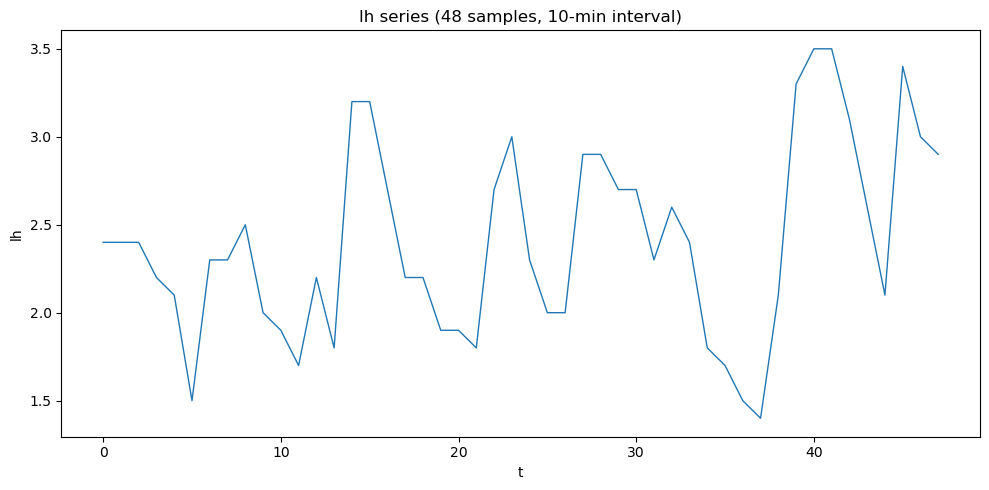

In [3]:
lh = np.array([2.4, 2.4, 2.4, 2.2, 2.1, 1.5, 2.3, 2.3, 2.5, 2.0, 1.9, 1.7, 2.2, 1.8, 3.2, 3.2, 2.7, 2.2, 2.2, 1.9, 1.9, 1.8, 2.7, 3.0, 2.3, 2.0, 2.0, 2.9, 2.9, 2.7, 2.7, 2.3, 2.6, 2.4, 1.8, 1.7, 1.5, 1.4, 2.1, 3.3, 3.5, 3.5, 3.1, 2.6, 2.1, 3.4, 3.0, 2.9], dtype=float)
plot_series(pd.Series(lh), "lh series (48 samples, 10-min interval)", ylabel="lh")

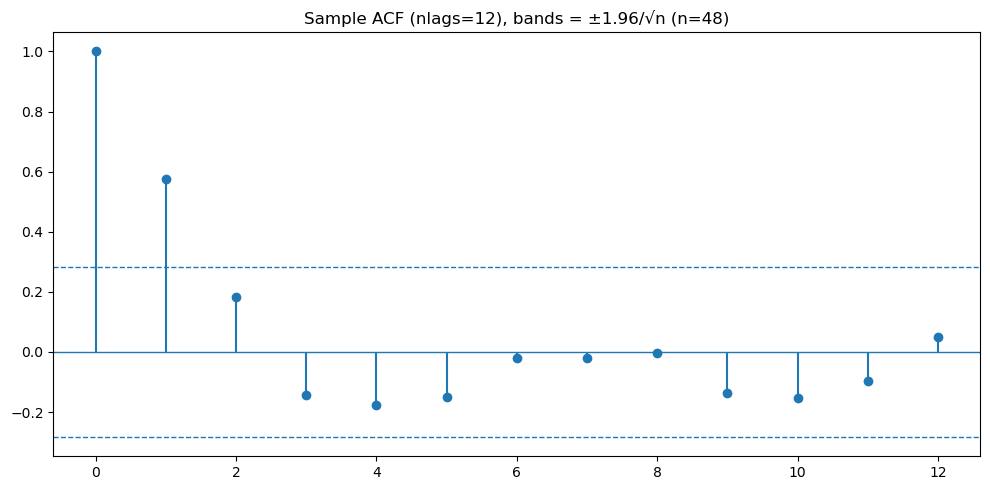

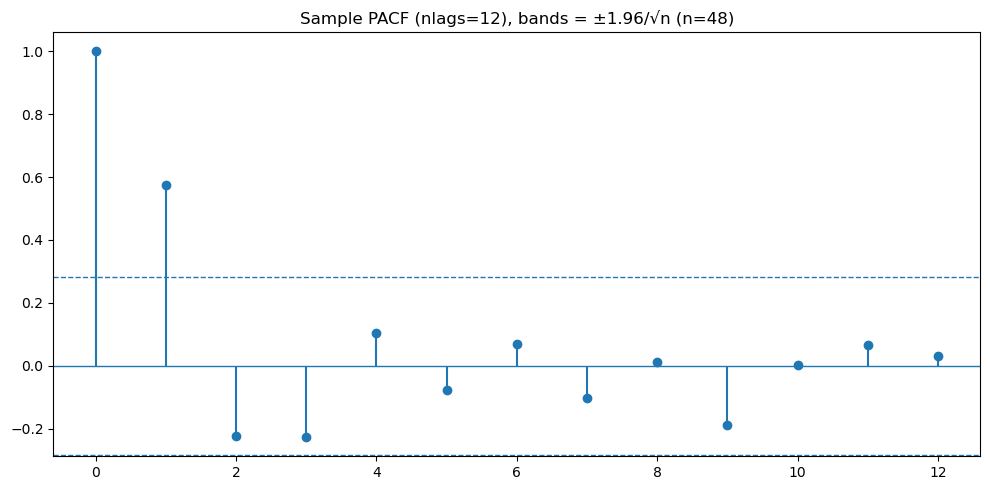

In [4]:
acf_lh, pacf_lh = plot_acf_pacf(lh, nlags=12)

### Fit a small candidate set and compare AIC/BIC


In [5]:
candidates = {
    "AR(1)": (1,0,0),
    "AR(2)": (2,0,0),
    "AR(3)": (3,0,0),
    "ARMA(1,1)": (1,0,1),
}
fits = {name: ARIMA(lh, order=order, trend="c").fit() for name, order in candidates.items()}

summary = pd.DataFrame({
    "model": list(fits.keys()),
    "AIC": [fits[m].aic for m in fits],
    "BIC": [fits[m].bic for m in fits],
}).sort_values("AIC")
summary

,model,AIC,BIC
2,AR(3),64.184822,73.540827
1,AR(2),64.503753,71.988557
0,AR(1),64.758325,70.371928
3,"ARMA(1,1)",65.524066,73.008870


### Residual diagnostics (ACF + Ljung–Box)
Interpretation:
- residual ACF should have no significant spikes
- Ljung–Box p-values should typically be > 0.05 (do not reject whiteness)


In [6]:
best_name = summary.iloc[0]["model"]
best_fit = fits[best_name]
print("Selected by AIC:", best_name)
print(best_fit.summary())

resid, lb = residual_report(best_fit, lags=(5,10,15,20))
lb

Selected by AIC: AR(3)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   48
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 -27.092
Date:                Tue, 10 Mar 2026   AIC                             64.185
Time:                        23:49:32   BIC                             73.541
Sample:                             0   HQIC                            67.720
                                 - 48                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3931      0.124     19.242      0.000       2.149       2.637
ar.L1          0.6448      0.195      3.309      0.001       0.263       1.027
ar.L2         -0.0634      0.

,lb_stat,lb_pvalue
5,0.685678,0.983745
10,3.862774,0.953325
15,7.363007,0.946783
20,9.476993,0.976695


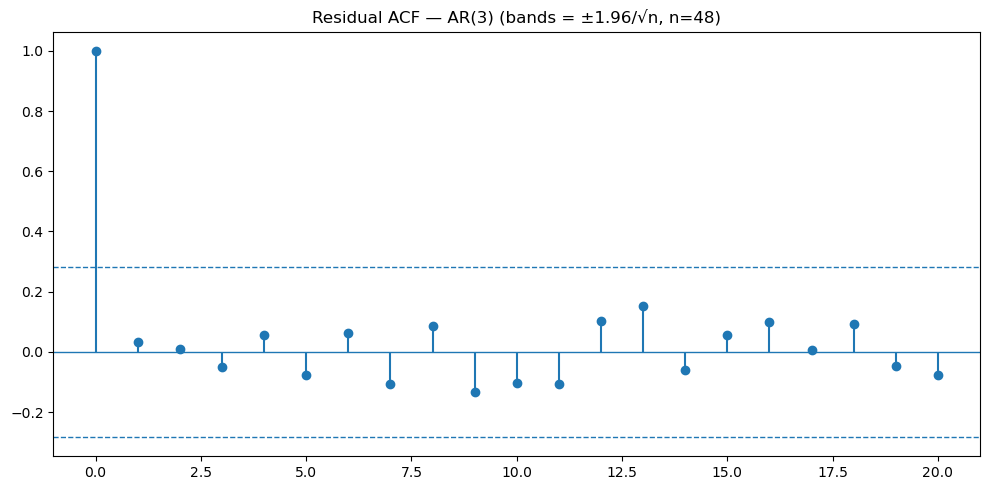

In [7]:
plot_resid_acf(resid, nlags=20, title=f"Residual ACF — {best_name}")

### Forecast (12 steps) + prediction intervals
Interpretation:
- point forecast is the model’s conditional mean forecast
- prediction interval quantifies uncertainty and widens with horizon


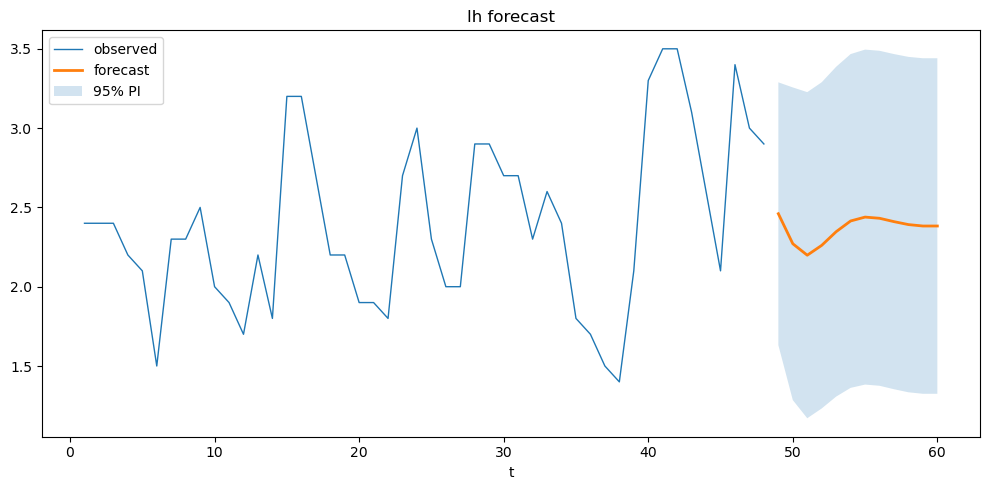

,forecast,lower_95,upper_95
49,2.460187,1.631752,3.288622
50,2.270849,1.285126,3.256573
51,2.198615,1.170568,3.226662
52,2.260706,1.232286,3.289125
53,2.346935,1.307083,3.386787
54,2.414478,1.362150,3.466806
55,2.438918,1.382888,3.494948
56,2.431444,1.375335,3.487553
57,2.410230,1.353613,3.466848
58,2.391653,1.334227,3.449080


In [8]:
fc_df = forecast_table_and_plot(best_fit, steps=12, y=lh, title_prefix="lh forecast")
fc_df

### Forecasting benchmarks: SES vs Holt (no seasonality expected)
Interpretation:
- SES: adaptive level only
- Holt: level + trend; may overreact if trend is not stable


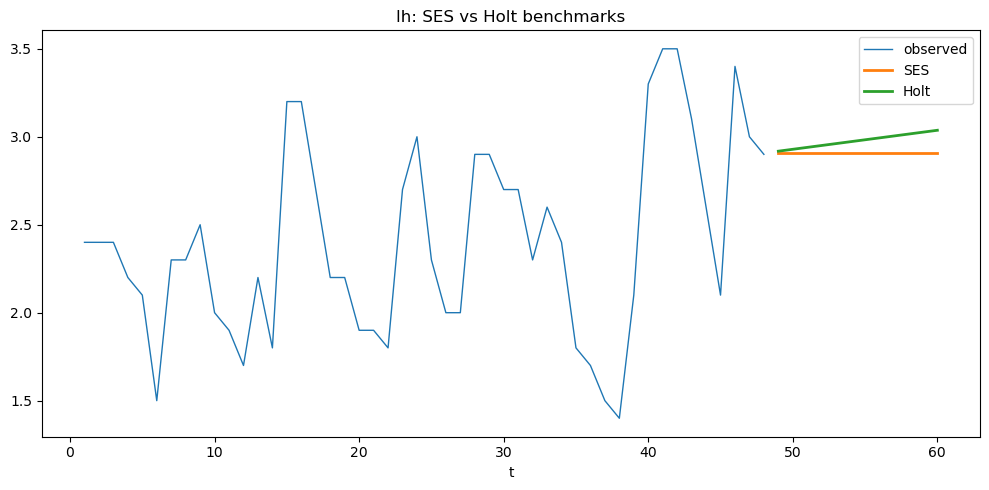

In [9]:
ses, holt, hw = ets_benchmarks(lh)
plot_ets_forecasts(lh, steps=12, ses=ses, holt=holt, hw=None, title="lh: SES vs Holt benchmarks")

## Example 2 — Annual oil production (Saudi Arabia), 1965–2013
**Goal:** show trend / nonstationarity handling and compare ARIMA vs ETS benchmarks.

### Why differencing and why `trend="n"` in ARIMA(p,1,q)?
The oil series exhibits long-run level changes (nonstationary behavior). A standard Box–Jenkins move is to difference once:
$$
\nabla X_t = X_t - X_{t-1}.
$$
If $\nabla X_t$ is approximately stationary, we fit:
$$
\nabla X_t \sim \mathrm{ARMA}(p,q)\quad\Longleftrightarrow\quad X_t \sim \mathrm{ARIMA}(p,1,q).
$$

**Software detail (statsmodels):** when $d=1$, a constant trend term would be eliminated by differencing, so we should not use `trend="c"`.
We use `trend="n"` (no trend) for ARIMA(p,1,q) grid search.


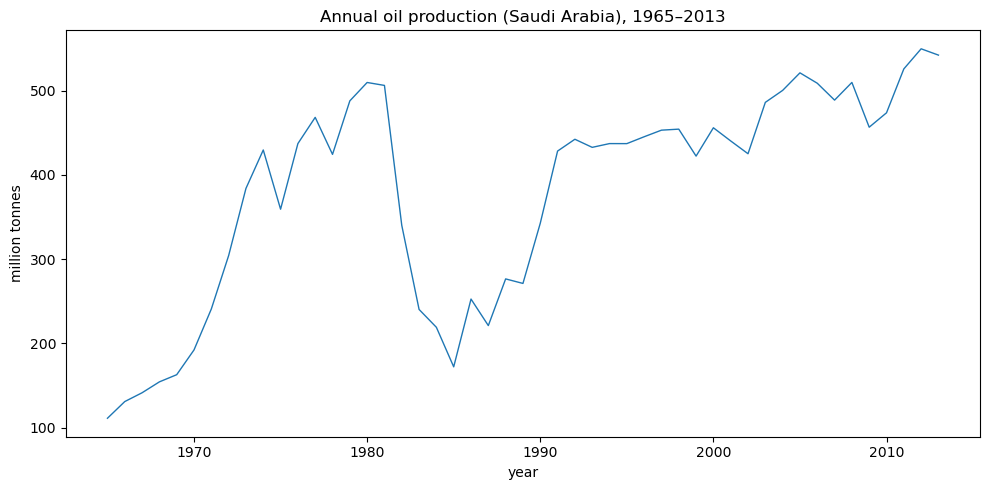

In [10]:
oil = np.array([111.0091, 130.8284, 141.2871, 154.2278, 162.7409, 192.1665, 240.7997, 304.2174, 384.0046, 429.6622, 359.3169, 437.2519, 468.4008, 424.4353, 487.9794, 509.8284, 506.3473, 340.1842, 240.2589, 219.0328, 172.0747, 252.5901, 221.0711, 276.5188, 271.148, 342.6186, 428.3558, 442.3946, 432.7851, 437.2497, 437.2092, 445.3641, 453.195, 454.4096, 422.3789, 456.0371, 440.3866, 425.1944, 486.2052, 500.4291, 521.2759, 508.9476, 488.8889, 509.8706, 456.7229, 473.8166, 525.9509, 549.8338, 542.3405], dtype=float)
years = np.arange(1965, 1965+len(oil))
oil_s = pd.Series(oil, index=pd.Index(years, name="year"), name="oil")
plot_series(oil_s, "Annual oil production (Saudi Arabia), 1965–2013", xlabel="year", ylabel="million tonnes")

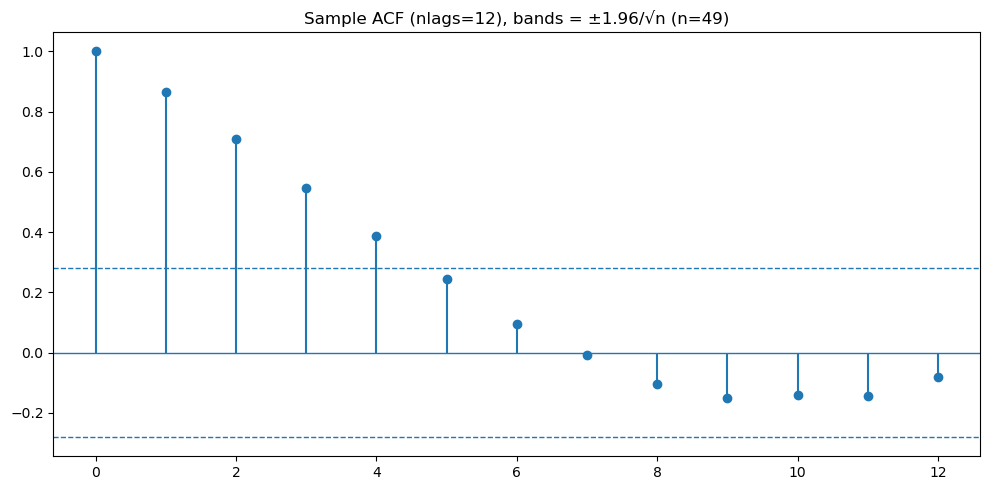

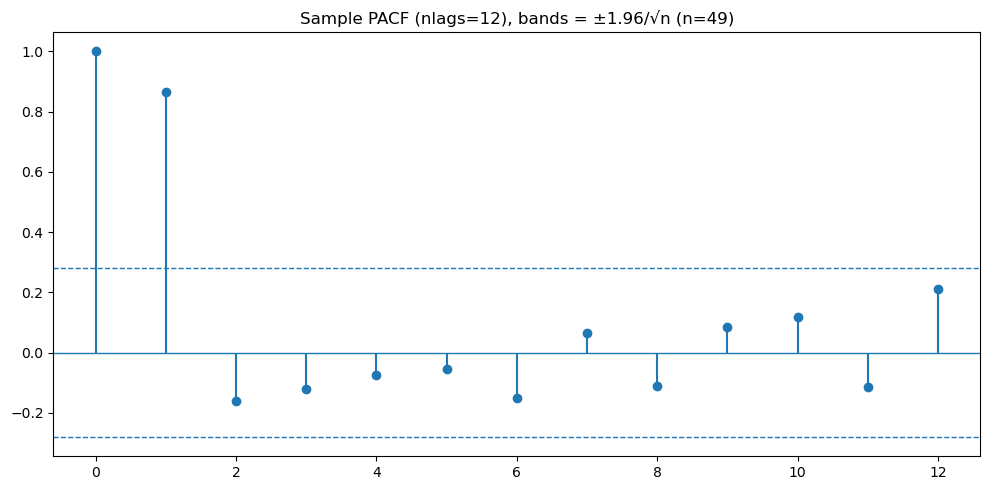

In [11]:
acf_oil, pacf_oil = plot_acf_pacf(oil, nlags=12)

### Differencing check
We difference once and re-check ACF/PACF. If differencing removes slow decay, ARIMA(p,1,q) is reasonable.


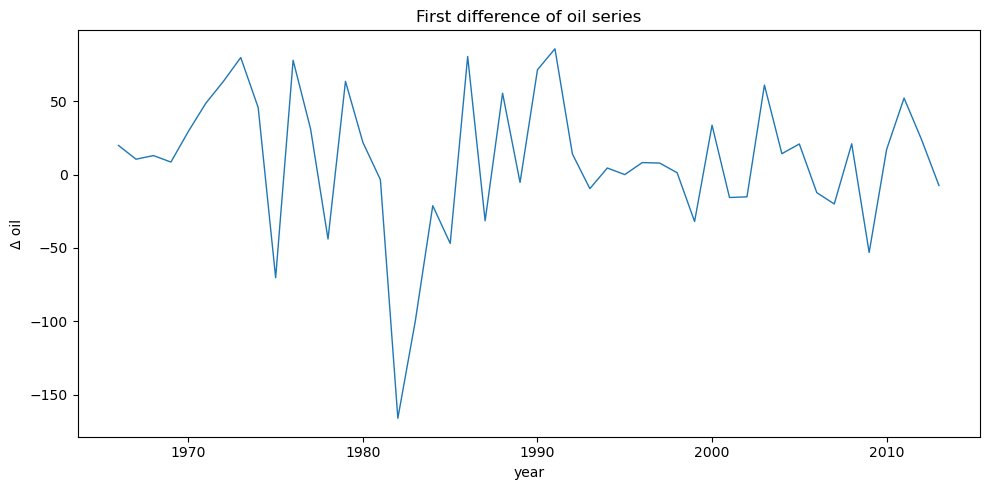

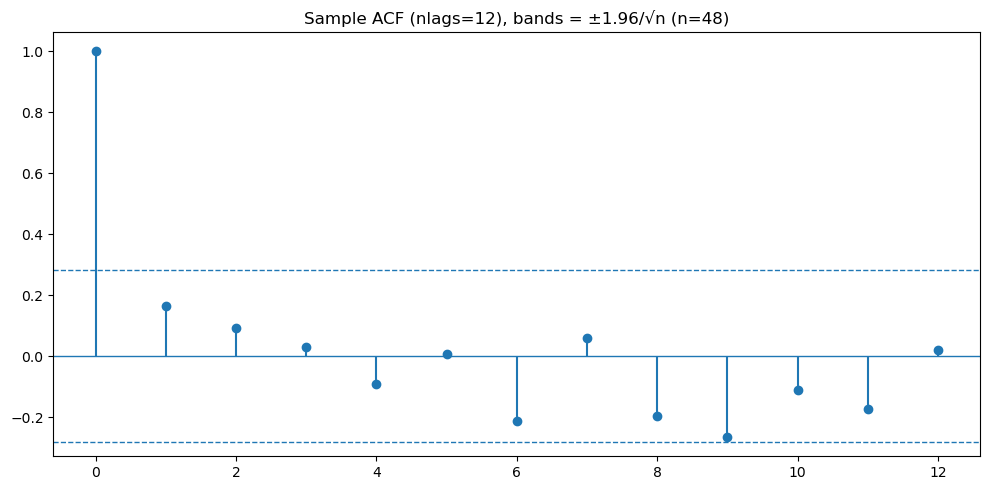

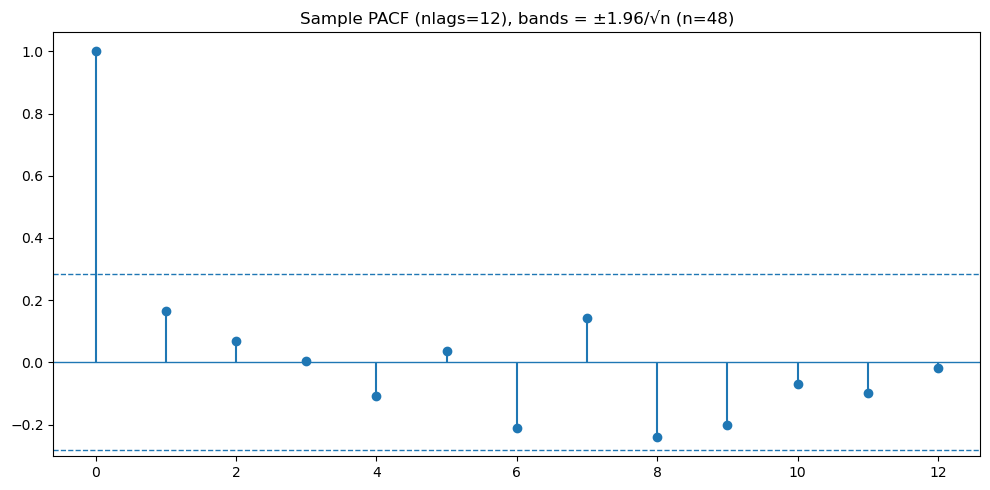

In [12]:
oil_diff = np.diff(oil)
plot_series(pd.Series(oil_diff, index=years[1:], name="diff(oil)"), "First difference of oil series", xlabel="year", ylabel="Δ oil")
acf_od, pacf_od = plot_acf_pacf(oil_diff, nlags=12)

### ARIMA order selection using AIC/BIC
We fit a small grid of candidates $\mathrm{ARIMA}(p,1,q)$, $p,q\in\{0,1,2\}$. We then select the model with the smallest AIC (tentatively), and validate via residual diagnostics.


In [13]:
grid = []
for p in range(0,3):
    for q in range(0,3):
        try:
            fit = ARIMA(oil, order=(p,0,q), trend="n").fit()
            grid.append({"order": (p,0,q), "AIC": float(fit.aic), "BIC": float(fit.bic)})
        except Exception:
            grid.append({"order": (p,0,q), "AIC": np.nan, "BIC": np.nan})
            
        try:
            fit = ARIMA(oil, order=(p,1,q), trend="n").fit()
            grid.append({"order": (p,1,q), "AIC": float(fit.aic), "BIC": float(fit.bic)})
        except Exception:
            grid.append({"order": (p,1,q), "AIC": np.nan, "BIC": np.nan})

grid_df = pd.DataFrame(grid).sort_values("AIC")
grid_df

C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


,order,AIC,BIC
1,"(0, 1, 0)",510.919664,512.790865
7,"(1, 1, 0)",511.111065,514.853467
3,"(0, 1, 1)",511.399311,515.141713
13,"(2, 1, 0)",512.756115,518.369718
9,"(1, 1, 1)",512.818480,518.432083
5,"(0, 1, 2)",512.833608,518.447211
11,"(1, 1, 2)",514.714650,522.199454
15,"(2, 1, 1)",514.749667,522.234471
17,"(2, 1, 2)",516.619047,525.975052
6,"(1, 0, 0)",527.521308,531.304949


In [14]:
best_order = tuple(grid_df.iloc[0]["order"])
fit_oil = ARIMA(oil, order=best_order, trend="n").fit()
print("Selected ARIMA order (by AIC):", best_order)
print(fit_oil.summary())

Selected ARIMA order (by AIC): (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   49
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -254.460
Date:                Tue, 10 Mar 2026   AIC                            510.920
Time:                        23:49:36   BIC                            512.791
Sample:                             0   HQIC                           511.627
                                 - 49                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2355.7538    366.680      6.425      0.000    1637.074    3074.434
Ljung-Box (L1) (Q):                   1.40   Jarque-Bera (JB):                19.54
Prob(Q

### Residual diagnostics (oil)
If the model is adequate, residuals should be approximately white noise:
- residual ACF: no systematic spikes
- Ljung–Box: p-values not too small (e.g. > 0.05)


In [15]:
resid_oil, lb_oil = residual_report(fit_oil, lags=(5,8,10,12))
lb_oil

,lb_stat,lb_pvalue
5,2.208176,0.819654
8,5.183131,0.737836
10,9.668878,0.470008
12,10.410257,0.580017


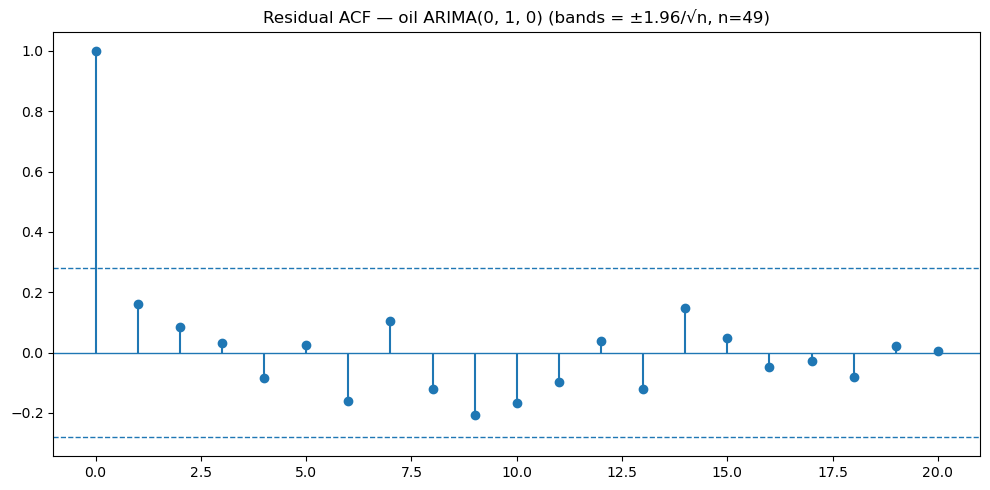

In [16]:
plot_resid_acf(resid_oil, nlags=20, title=f"Residual ACF — oil ARIMA{best_order}")

### Forecast next 8 years (ARIMA)
Interpretation:
- Prediction intervals should widen with horizon.
- Compare with ETS benchmarks (SES/Holt) as a sanity check.


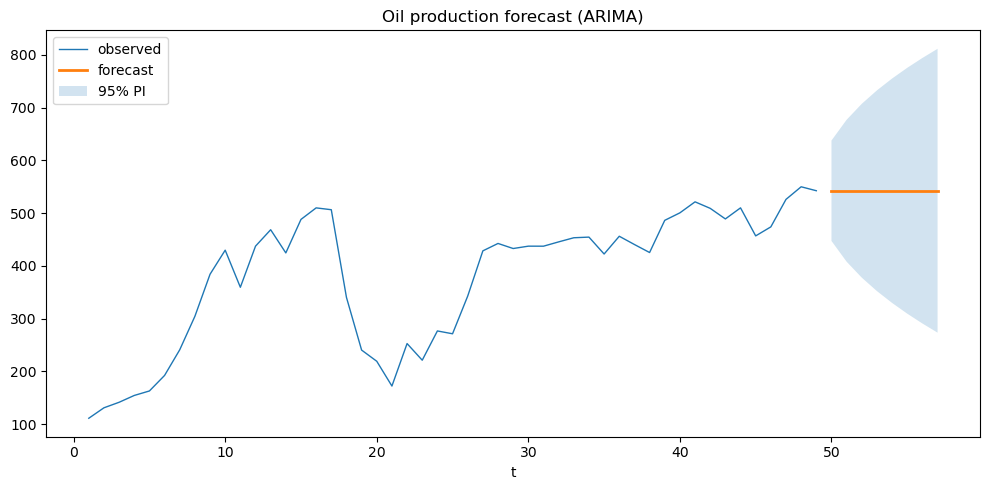

,forecast,lower_95,upper_95
50,542.3405,447.211476,637.469524
51,542.3405,407.807744,676.873256
52,542.3405,377.572197,707.108803
53,542.3405,352.082452,732.598548
54,542.3405,329.625536,755.055464
55,542.3405,309.322931,775.358069
56,542.3405,290.652760,794.028240
57,542.3405,273.274988,811.406012


In [17]:
fc_oil = forecast_table_and_plot(fit_oil, steps=8, y=oil, title_prefix="Oil production forecast (ARIMA)")
fc_oil

### Forecasting benchmarks: SES vs Holt (annual, trend likely)
Interpretation:
- SES is purely level smoothing.
- Holt adds a trend component and often improves trend forecasting.


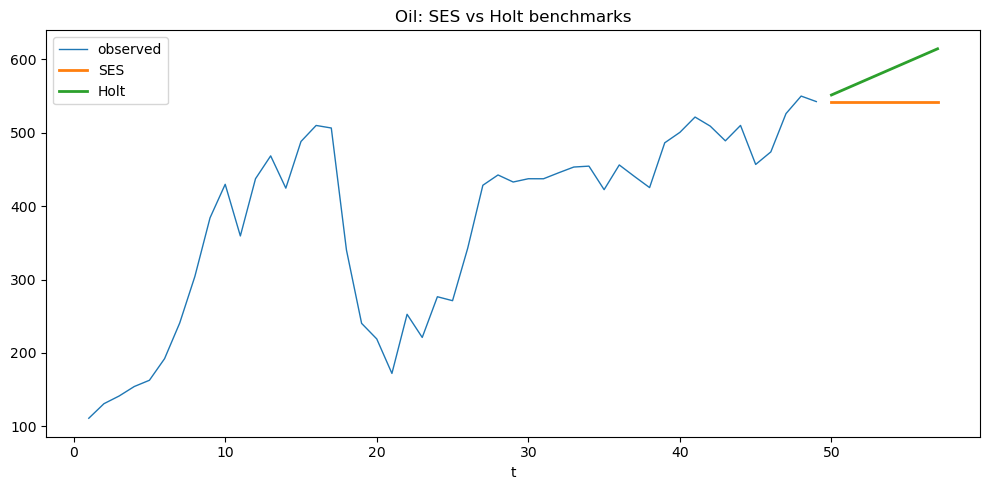

In [18]:
ses_o, holt_o, _ = ets_benchmarks(oil)
plot_ets_forecasts(oil, steps=8, ses=ses_o, holt=holt_o, hw=None, title="Oil: SES vs Holt benchmarks")

## Example 3 — Australian tourists (quarterly), 1999–2015
**Goal:** demonstrate seasonality, Holt–Winters benchmarks, and a SARIMA-style model.


In [19]:
df = pd.read_csv("austourists.csv")

# Rename the year column (currently 'Unnamed: 0')
df = df.rename(columns={"Unnamed: 0": "Year"})

# Wide -> long: one row per (Year, Quarter)
long = df.melt(
    id_vars=["Year"],
    value_vars=["Qtr1", "Qtr2", "Qtr3", "Qtr4"],
    var_name="Quarter",
    value_name="tourists"
).sort_values(["Year", "Quarter"]).reset_index(drop=True)

# Build a proper quarterly PeriodIndex: Year + quarter number
q_num = long["Quarter"].str.replace("Qtr", "", regex=False).astype(int)
period = pd.PeriodIndex(year=long["Year"].astype(int), quarter=q_num, freq="Q")
tour_s = pd.Series(long["tourists"].astype(float).to_numpy(),
                   index=period.to_timestamp(),
                   name="tourists")

len(tour_s), tour_s.head(), tour_s.tail()

C:\Users\pig_p\AppData\Local\Temp\ipykernel_36940\430354351.py:16: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  period = pd.PeriodIndex(year=long["Year"].astype(int), quarter=q_num, freq="Q")


(68,
 1999-01-01    30.05251
 1999-04-01    19.14850
 1999-07-01    25.31769
 1999-10-01    27.59144
 2000-01-01    32.07646
 Freq: QS-OCT, Name: tourists, dtype: float64,
 2014-10-01    59.83447
 2015-01-01    73.25703
 2015-04-01    47.69662
 2015-07-01    61.09777
 2015-10-01    66.05576
 Freq: QS-OCT, Name: tourists, dtype: float64)

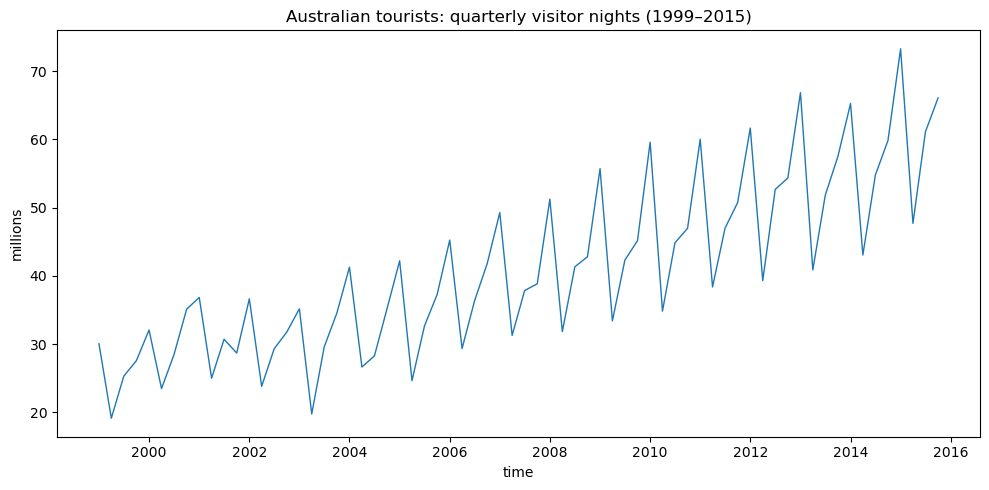

In [20]:
plot_series(tour_s, "Australian tourists: quarterly visitor nights (1999–2015)", xlabel="time", ylabel="millions")

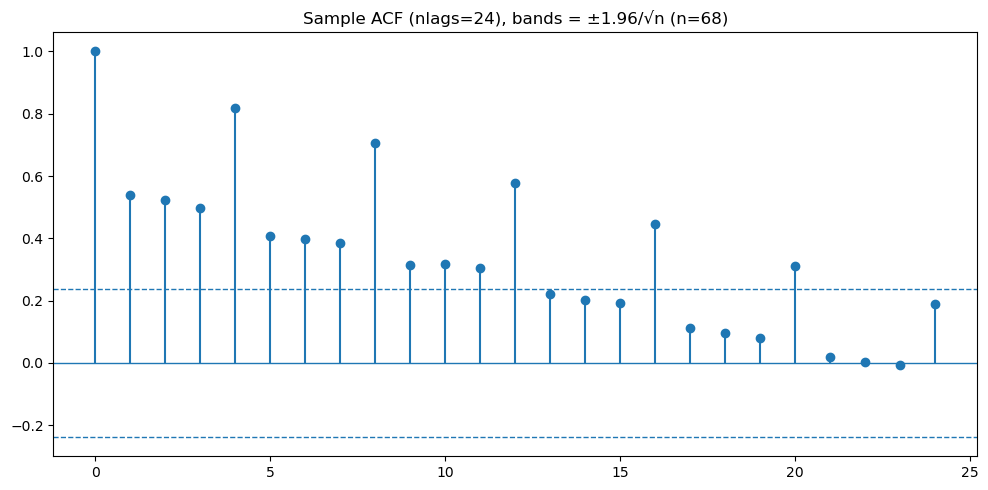

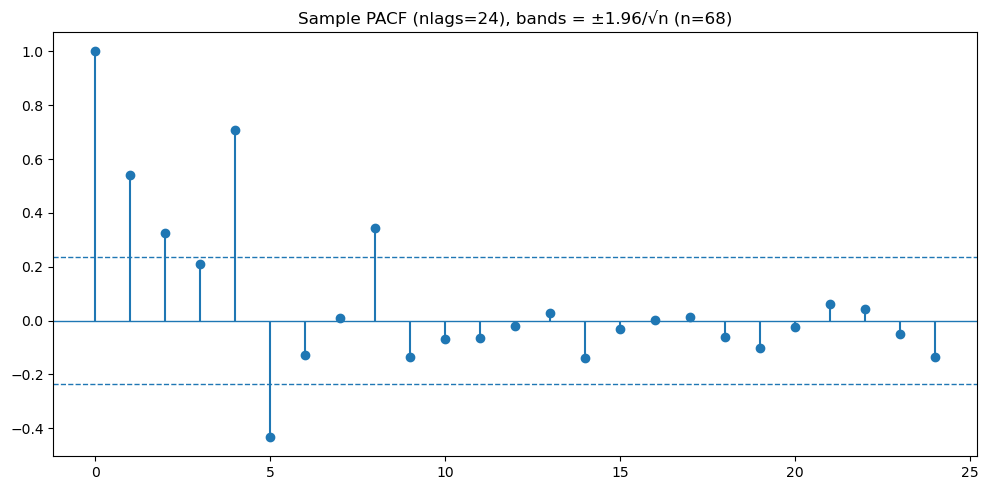

In [21]:
acf_t, pacf_t = plot_acf_pacf(tour_s.values, nlags=24)

### Holt–Winters benchmarks (seasonal period = 4)
Interpretation:
- Holt–Winters captures both trend and quarterly seasonality.
- Use it as a strong baseline before SARIMA.


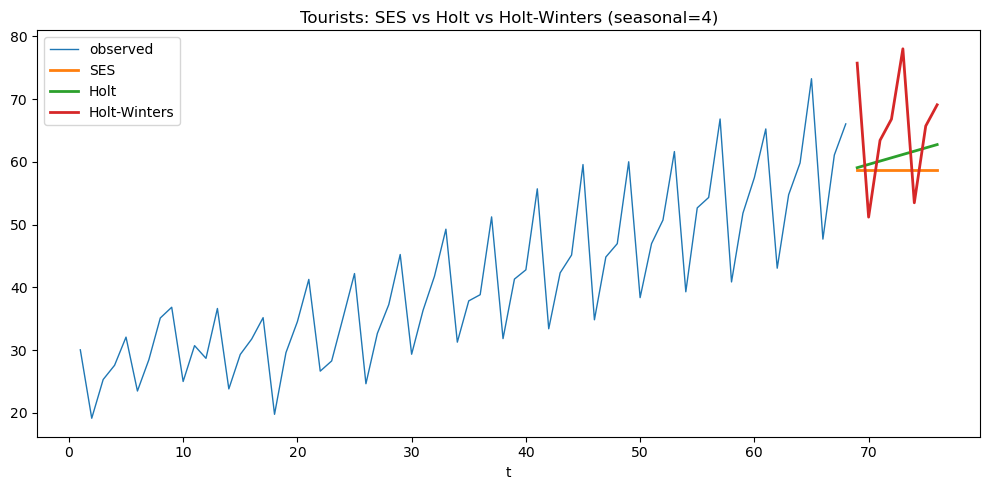

In [22]:
ses_t, holt_t, hw_t = ets_benchmarks(tour_s.values, seasonal_periods=4, seasonal="add")
plot_ets_forecasts(tour_s.values, steps=8, ses=ses_t, holt=holt_t, hw=hw_t, title="Tourists: SES vs Holt vs Holt-Winters (seasonal=4)")

### A simple seasonal ARIMA candidate (example): (0,1,1)×(0,1,1,4)
This is a common seasonal baseline.

Diagnostics rule:
- residual ACF should show no leftover seasonal spikes
- Ljung–Box should not reject whiteness at typical lags


In [23]:
sarima = ARIMA(tour_s.values, order=(0,1,1), seasonal_order=(0,1,1,4), trend="n").fit()
print(sarima.summary())

resid_s, lb_s = residual_report(sarima, lags=(8,12,16,20))
lb_s

                                    SARIMAX Results                                    
Dep. Variable:                               y   No. Observations:                   68
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 4)   Log Likelihood                -144.282
Date:                         Tue, 10 Mar 2026   AIC                            294.564
Time:                                 23:49:39   BIC                            300.993
Sample:                                      0   HQIC                           297.093
                                          - 68                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6052      0.118     -5.137      0.000      -0.836      -0.374
ma.S.L4       -0.5089      0.140     -3.629      0.000     

,lb_stat,lb_pvalue
8,12.155744,0.144389
12,15.519281,0.214259
16,16.211048,0.438331
20,18.014681,0.586441


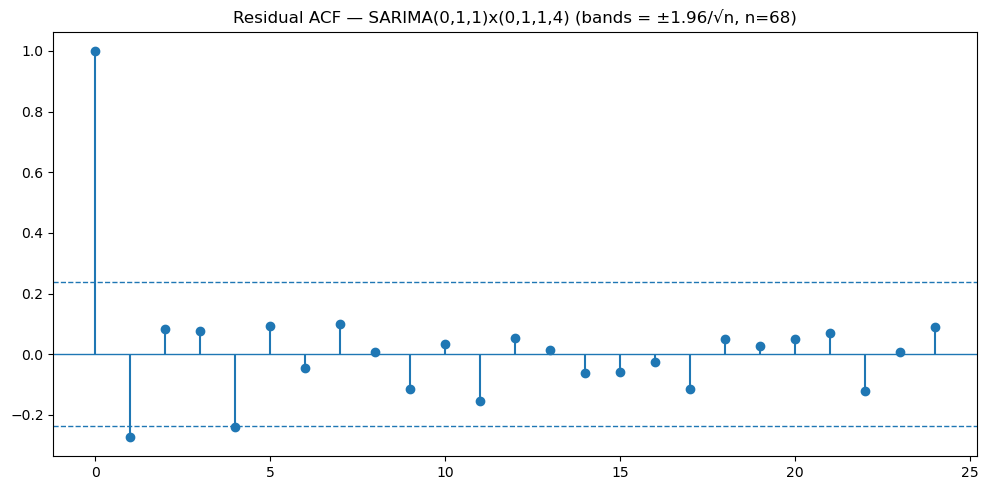

In [24]:
plot_resid_acf(sarima.resid, nlags=24, title="Residual ACF — SARIMA(0,1,1)x(0,1,1,4)")

### Forecast next 8 quarters (SARIMA)


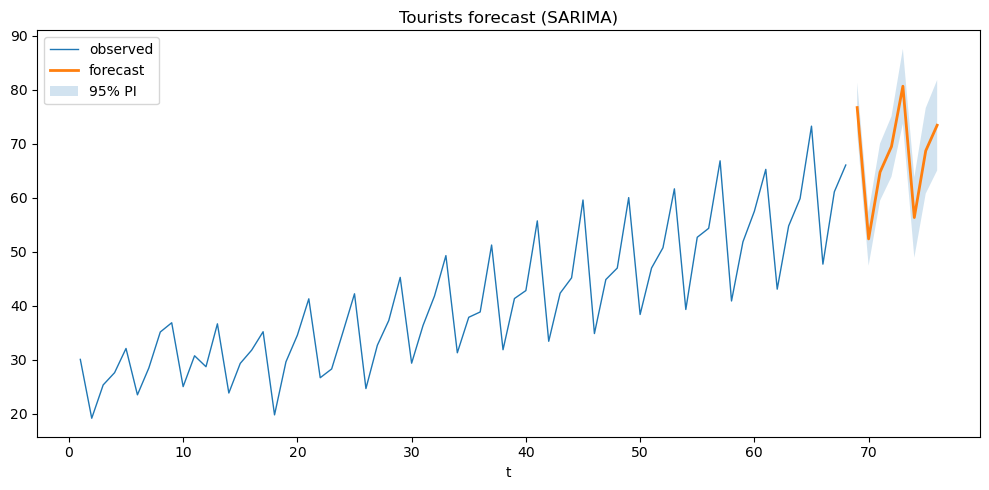

,forecast,lower_95,upper_95
69,76.702284,72.084472,81.320095
70,52.377152,47.412556,57.341747
71,64.739420,59.450731,70.028108
72,69.474116,63.880079,75.068153
73,80.654617,73.724560,87.584674
74,56.329485,48.885453,63.773517
75,68.691753,60.767011,76.616495
76,73.426450,65.048535,81.804365


In [25]:
fc_t = forecast_table_and_plot(sarima, steps=8, y=tour_s.values, title_prefix="Tourists forecast (SARIMA)")
fc_t